In [6]:
%matplotlib inline

In [7]:
import numpy as np
import scipy.signal
import matplotlib.pyplot as plt

# Generate multivariate time series, each of them a linear combination of
# sinusoids with different period length |f0| and variance |f0Var|.
# Furthermore, red noise realized as an AR(1) process with a noise level
# |NoiseLevel| is added. The AR(1) parameters are randomly chosen in
# |ARCoeff|.

# clear all

t = np.arange(1, 10030).reshape(-1, 1)
t = np.arange(1, 1030).reshape(-1, 1)
t = np.arange(1, 130).reshape(-1, 1)

f0 = 1.0 / np.array([7.5, 5.0, 2.8, 2.3])

f0Var = np.array([
    [0.4, 0.0, 0.3, 0.3],
    [0.4, 0.2, 0.4, 0.0],
    [0.3, 0.3, 0.0, 0.4],
    [0.0, 0.4, 0.4, 0.2],
    [0.2, 0.4, 0.0, 0.4],
    [0.3, 0.0, 0.4, 0.3],
])

D = f0Var.shape[0]
np.random.seed(0)
N = t.shape[0]

NoiseLevel = 0.6  ##
# NoiseLevel = 0.0  ##

ARCoeff = np.random.rand(1, D) * 0.1 + 0.55
ARVar = 1 - ARCoeff ** 2

# Combination of sinusoids
xreff = np.zeros((N, D, len(f0)))
xref = np.zeros((N, D))
beta = np.zeros((D, len(f0)))

for d in range(D):
    for pos in range(len(f0)):
        beta[d, pos] = np.random.rand() * 2 * np.pi
        xreff[:, d, pos] = (
            np.sqrt(f0Var[d, pos])
            * np.sin(2 * np.pi * f0[pos] * t + beta[d, pos]).squeeze()
        )

xref = np.squeeze(np.sum(xreff, axis=2))

In [8]:
xref1 = np.squeeze(xreff[:, :, 0]) / np.sqrt(0.5) * np.sqrt(1 - NoiseLevel)
xref2 = np.squeeze(xreff[:, :, 1]) / np.sqrt(0.5) * np.sqrt(1 - NoiseLevel)
xref3 = np.squeeze(xreff[:, :, 2]) / np.sqrt(0.5) * np.sqrt(1 - NoiseLevel)
xref4 = np.squeeze(xreff[:, :, 3]) / np.sqrt(0.5) * np.sqrt(1 - NoiseLevel)

In [9]:
xref = xref / np.sqrt(0.5)

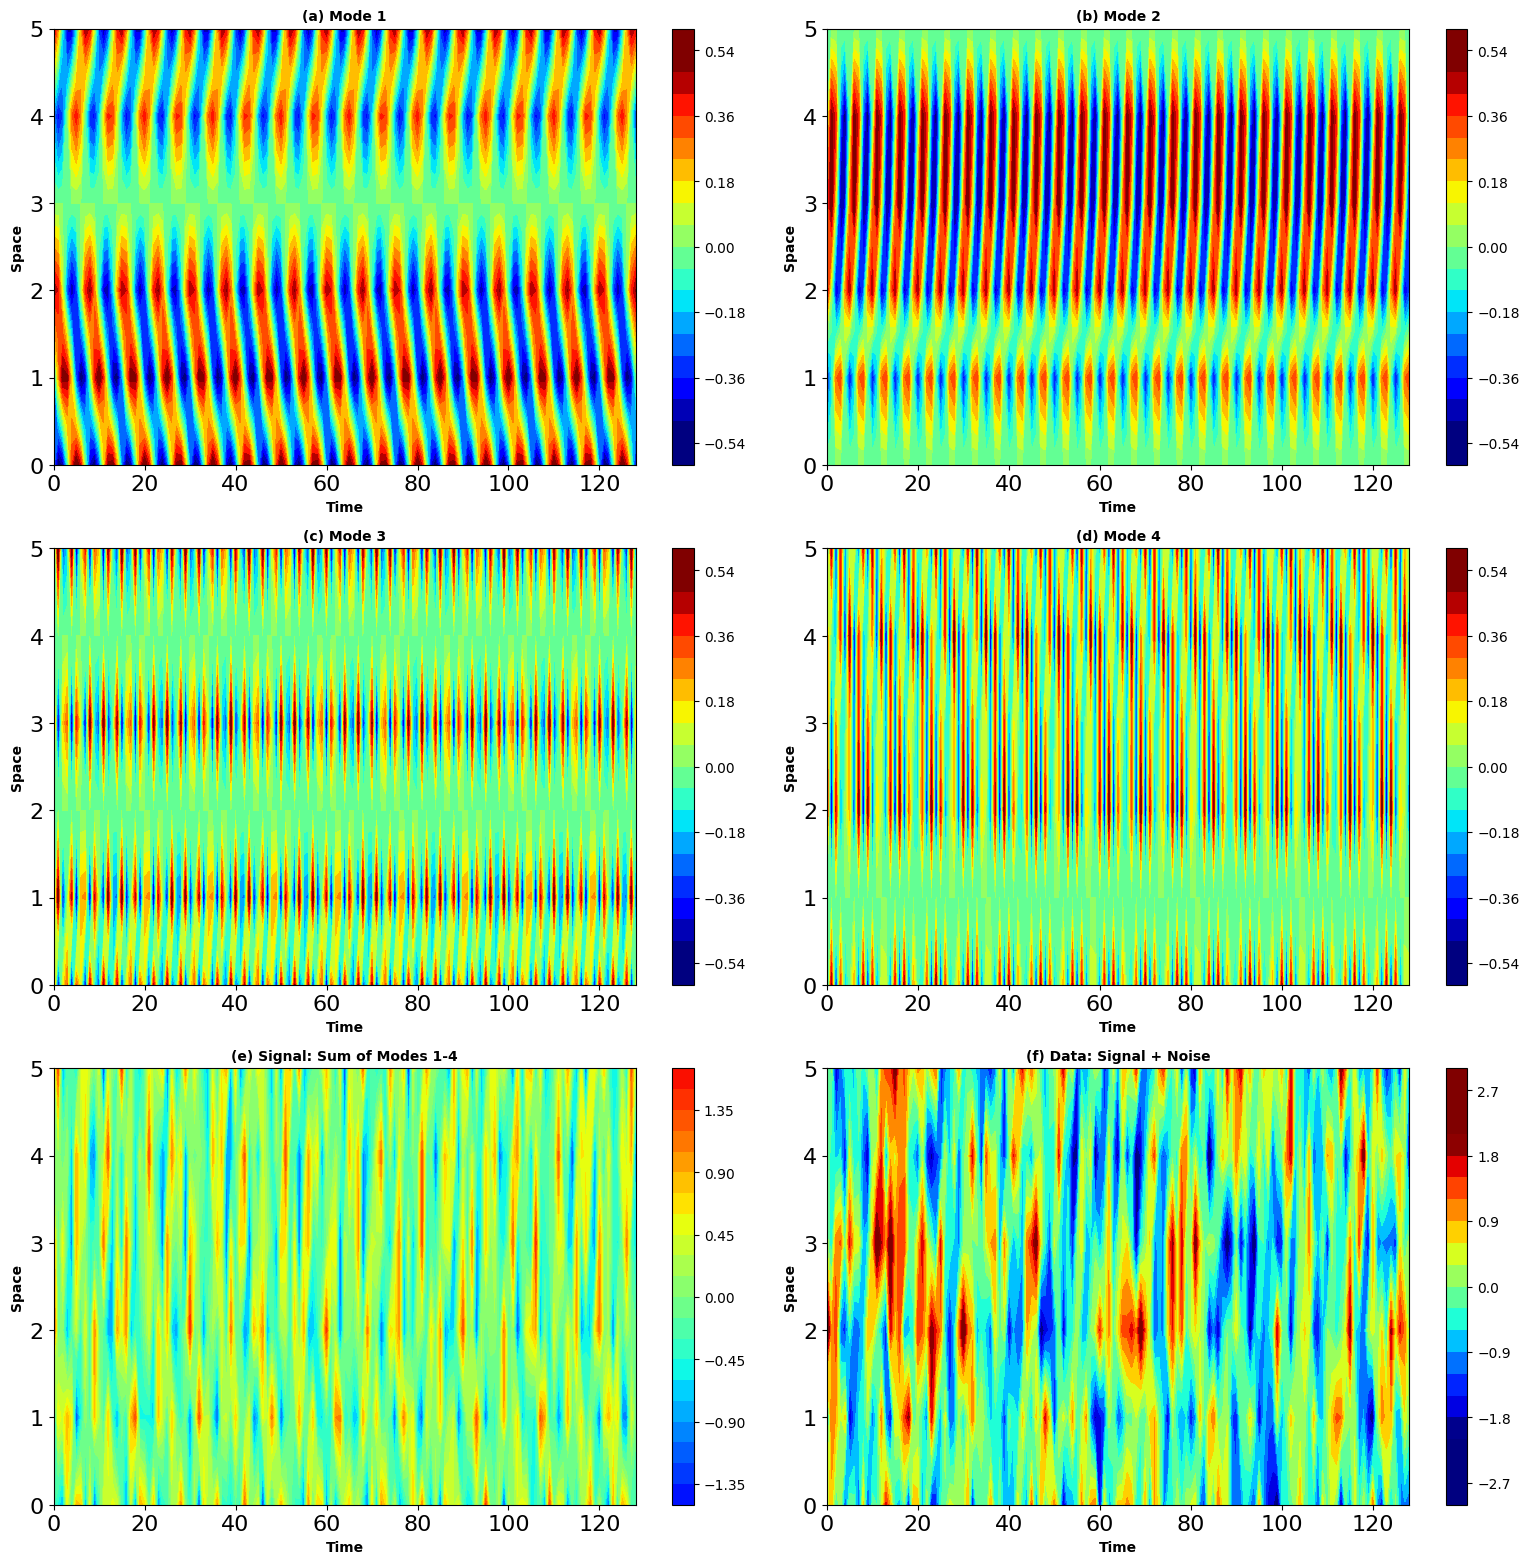

In [10]:
# AR(1) process
r = np.random.randn(N, D)
for d in range(D):
    r[:, d] = scipy.signal.lfilter(
        [np.sqrt(ARVar[0, d])], [1, -ARCoeff[0, d]], r[:, d]
    )

# Sinusoid + AR(1)
data = np.sqrt(1 - NoiseLevel) * xref + np.sqrt(NoiseLevel) * r
noise = np.sqrt(NoiseLevel) * r
xref = np.sqrt(1 - NoiseLevel) * xref

signal = xref
x = data

xmax = 0.5
xmin = -0.5
iplot = 1

if iplot == 1:
    fig = plt.figure(figsize=(40 / 2.54, 40 / 2.54), dpi=100)
    plt.rcParams.update({
        'axes.labelweight': 'bold',
        'axes.titleweight': 'bold',
        'axes.labelsize': 10,
        'axes.titlesize': 10,
    })

    plt.subplot(321)
    cf = plt.contourf(xref1.T, 20, cmap='jet', vmin=xmin, vmax=xmax)
    plt.colorbar(cf)
    plt.title('(a) Mode 1')
    plt.xlabel('Time')
    plt.ylabel('Space')
    plt.gca().tick_params(labelsize=16)

    plt.subplot(322)
    plt.gca().tick_params(labelsize=16)
    cf = plt.contourf(xref2.T, 20, cmap='jet', vmin=xmin, vmax=xmax)
    plt.colorbar(cf)
    plt.title('(b) Mode 2')
    plt.xlabel('Time')
    plt.ylabel('Space')
    plt.gca().tick_params(labelsize=16)

    plt.subplot(323)
    plt.gca().tick_params(labelsize=16)
    cf = plt.contourf(xref3.T, 20, cmap='jet', vmin=xmin, vmax=xmax)
    plt.colorbar(cf)
    plt.title('(c) Mode 3')
    plt.xlabel('Time')
    plt.ylabel('Space')
    plt.gca().tick_params(labelsize=16)

    plt.subplot(324)
    plt.gca().tick_params(labelsize=16)
    cf = plt.contourf(xref4.T, 20, cmap='jet', vmin=xmin, vmax=xmax)
    plt.colorbar(cf)
    plt.title('(d) Mode 4')
    plt.xlabel('Time')
    plt.ylabel('Space')
    plt.gca().tick_params(labelsize=16)

    plt.subplot(325)
    plt.gca().tick_params(labelsize=16)
    cf = plt.contourf(signal.T, 20, cmap='jet', vmin=-2, vmax=2)
    plt.colorbar(cf)
    plt.title('(e) Signal: Sum of Modes 1-4')
    plt.xlabel('Time')
    plt.ylabel('Space')
    plt.gca().tick_params(labelsize=16)

    plt.subplot(326)
    plt.gca().tick_params(labelsize=16)
    cf = plt.contourf(data.T, 20, cmap='jet', vmin=-2, vmax=2)
    plt.colorbar(cf)
    plt.title('(f) Data: Signal + Noise')
    plt.xlabel('Time')
    plt.ylabel('Space')
    plt.gca().tick_params(labelsize=16)

    plt.tight_layout()
    plt.show()